In [1]:
# ═══════════════════════════════════════════════════════════════════
# 0. IMPORTS & GLOBAL CONFIG
# ═══════════════════════════════════════════════════════════════════
import os
import sys
import random
import warnings
import time
from pathlib import Path
from collections import defaultdict

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    average_precision_score, precision_recall_curve, auc,
    confusion_matrix, classification_report,
)

# --- PyTorch Geometric ---
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, SAGEConv, GATConv
from torch_geometric.utils import to_undirected

try:
    from torch_geometric.loader import NeighborLoader
    HAS_NEIGHBOR_LOADER = True
except ImportError:
    HAS_NEIGHBOR_LOADER = False

try:
    from torch_geometric.explain import Explainer, GNNExplainer
    HAS_EXPLAINER = True
except ImportError:
    HAS_EXPLAINER = False

try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

# ── Reproducibility ──
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Plot style ──
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["figure.figsize"] = (12, 5)

print(f"PyTorch {torch.__version__}  |  Device: {DEVICE}")
print(f"NeighborLoader: {HAS_NEIGHBOR_LOADER}  |  GNNExplainer: {HAS_EXPLAINER}")
print(f"XGBoost: {HAS_XGB}")


# ═══════════════════════════════════════════════════════════════════
# 1. DATA LOADING
# ═══════════════════════════════════════════════════════════════════

def discover_data_dir():
    """Auto-discover the Elliptic dataset directory."""
    candidates = [
        "./elliptic_bitcoin_dataset",
        "../input/elliptic-data-set/elliptic_bitcoin_dataset",
        # Kaggle paths
        "/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset",
        "/kaggle/input/elliptic-data-set/elliptic_bitcoin_dataset",
    ]
    for c in candidates:
        if os.path.isdir(c):
            return c

    # Try kagglehub download
    try:
        import kagglehub
        path = kagglehub.dataset_download("ellipticco/elliptic-data-set")
        d = os.path.join(path, "elliptic_bitcoin_dataset")
        if os.path.isdir(d):
            return d
    except Exception:
        pass

    raise FileNotFoundError(
        "Could not find the Elliptic dataset. "
        "Download from https://www.kaggle.com/datasets/ellipticco/elliptic-data-set "
        "and place the 'elliptic_bitcoin_dataset/' folder in the working directory."
    )


DATA_DIR = discover_data_dir()
print(f"\nDataset directory: {DATA_DIR}")

# Load raw CSVs
feat_cols = ["txId", "timestep"] + [f"f{i}" for i in range(1, 166)]
df_features = pd.read_csv(os.path.join(DATA_DIR, "elliptic_txs_features.csv"),
                           header=None, names=feat_cols)
df_edges    = pd.read_csv(os.path.join(DATA_DIR, "elliptic_txs_edgelist.csv"))
df_classes  = pd.read_csv(os.path.join(DATA_DIR, "elliptic_txs_classes.csv"))

print(f"Features : {df_features.shape}")
print(f"Edges    : {df_edges.shape}")
print(f"Classes  : {df_classes['class'].value_counts().to_dict()}")

PyTorch 2.10.0+cu128  |  Device: cuda
NeighborLoader: True  |  GNNExplainer: True
XGBoost: True

Dataset directory: /kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset
Features : (203769, 167)
Edges    : (234355, 2)
Classes  : {'unknown': 157205, '2': 42019, '1': 4545}


In [2]:
# ═══════════════════════════════════════════════════════════════════
# 2. GRAPH CONSTRUCTOR — Handles all preprocessing
# ═══════════════════════════════════════════════════════════════════

class GraphConstructor:
    """
    Builds PyG Data objects from the Elliptic raw CSVs.

    Key design decisions (sourced from best-performing groups):
      - Leak-free scaling: scaler fitted on train nodes ONLY.
      - Temporal split: ts 1-34 train, 35-38 val, 39-49 test.
      - Unknown labels masked to -1 (excluded from loss).
      - Supports full (165) or ablated (94 local-only) features.
    """

    TRAIN_TS_MAX = 34
    VAL_TS_MAX   = 38  # val: 35-38, test: 39-49

    def __init__(self, df_features, df_edges, df_classes, use_local_only=False):
        self.use_local_only = use_local_only
        self._build(df_features, df_edges, df_classes)

    def _build(self, df_feat, df_edges, df_cls):
        # ── Merge & label encode ──
        df = df_feat.merge(df_cls, on="txId", how="left")
        df["class"] = df["class"].fillna("unknown")
        label_map = {"1": 1, "2": 0, "unknown": -1}
        df["label"] = df["class"].astype(str).map(label_map)

        # ── Node ID mapping ──
        df = df.reset_index(drop=True)
        self.txid_to_idx = {txid: idx for idx, txid in enumerate(df["txId"])}
        N = len(df)

        # ── Feature matrix ──
        if self.use_local_only:
            feature_cols = [f"f{i}" for i in range(1, 95)]   # 94 local features
        else:
            feature_cols = [f"f{i}" for i in range(1, 166)]   # all 165

        X_raw = df[feature_cols].values.astype(np.float32)

        # ── Temporal masks (before scaling to avoid leakage) ──
        ts = df["timestep"].values
        labels = df["label"].values

        labeled   = labels != -1
        train_idx = labeled & (ts <= self.TRAIN_TS_MAX)
        val_idx   = labeled & (ts > self.TRAIN_TS_MAX) & (ts <= self.VAL_TS_MAX)
        test_idx  = labeled & (ts > self.VAL_TS_MAX)

        # ── Leak-free scaling: fit on train only ──
        scaler = StandardScaler()
        scaler.fit(X_raw[train_idx])
        X_scaled = scaler.transform(X_raw).astype(np.float32)

        # ── Edge index ──
        valid = (df_edges["txId1"].isin(self.txid_to_idx) &
                 df_edges["txId2"].isin(self.txid_to_idx))
        ef = df_edges[valid]
        src = ef["txId1"].map(self.txid_to_idx).values
        dst = ef["txId2"].map(self.txid_to_idx).values
        edge_index = torch.tensor(np.stack([src, dst]), dtype=torch.long)

        # ── Build PyG Data ──
        self.data = Data(
            x          = torch.tensor(X_scaled, dtype=torch.float),
            edge_index = edge_index,
            y          = torch.tensor(labels, dtype=torch.long),
            train_mask = torch.tensor(train_idx, dtype=torch.bool),
            val_mask   = torch.tensor(val_idx,   dtype=torch.bool),
            test_mask  = torch.tensor(test_idx,  dtype=torch.bool),
        )

        # Store timestep array for rolling-window
        self.data.timestep = torch.tensor(ts, dtype=torch.long)

        # Also store undirected version for GCN
        self.edge_index_undirected = to_undirected(edge_index)

        # Store raw data for XGBoost
        self._X_raw_scaled = X_scaled
        self._labels = labels
        self._train_idx = train_idx
        self._val_idx   = val_idx
        self._test_idx  = test_idx

        # Stats
        n_train_ill = (labels[train_idx] == 1).sum()
        n_train_lic = (labels[train_idx] == 0).sum()
        print(f"\n{'='*55}")
        print(f"  GraphConstructor Summary ({'94 local' if self.use_local_only else '165 full'} features)")
        print(f"{'='*55}")
        print(f"  Nodes          : {N:,}")
        print(f"  Edges          : {edge_index.shape[1]:,} directed")
        print(f"  Features       : {X_scaled.shape[1]}")
        print(f"  Train (labeled): {train_idx.sum():,}  (illicit: {n_train_ill}, licit: {n_train_lic})")
        print(f"  Val   (labeled): {val_idx.sum():,}")
        print(f"  Test  (labeled): {test_idx.sum():,}")
        print(f"  Imbalance ratio: 1:{n_train_lic / max(n_train_ill, 1):.1f}")
        print(f"{'='*55}\n")

    def get_data(self, device=None):
        d = self.data
        if device:
            d = d.to(device)
        return d

    def get_xgb_splits(self):
        """Return (X_train, y_train), (X_val, y_val), (X_test, y_test) for XGBoost."""
        return (
            (self._X_raw_scaled[self._train_idx], self._labels[self._train_idx]),
            (self._X_raw_scaled[self._val_idx],   self._labels[self._val_idx]),
            (self._X_raw_scaled[self._test_idx],  self._labels[self._test_idx]),
        )


# Build both full and ablated graphs
gc_full    = GraphConstructor(df_features, df_edges, df_classes, use_local_only=False)
gc_ablated = GraphConstructor(df_features, df_edges, df_classes, use_local_only=True)

data_full    = gc_full.get_data(DEVICE)
data_ablated = gc_ablated.get_data(DEVICE)


  GraphConstructor Summary (165 full features)
  Nodes          : 203,769
  Edges          : 234,355 directed
  Features       : 165
  Train (labeled): 29,894  (illicit: 3462, licit: 26432)
  Val   (labeled): 4,303
  Test  (labeled): 12,367
  Imbalance ratio: 1:7.6


  GraphConstructor Summary (94 local features)
  Nodes          : 203,769
  Edges          : 234,355 directed
  Features       : 94
  Train (labeled): 29,894  (illicit: 3462, licit: 26432)
  Val   (labeled): 4,303
  Test  (labeled): 12,367
  Imbalance ratio: 1:7.6



In [3]:
# ═══════════════════════════════════════════════════════════════════
# 3. FOCAL LOSS
# ═══════════════════════════════════════════════════════════════════

class FocalLoss(nn.Module):
    """
    Focal Loss: FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    Handles class imbalance by down-weighting easy examples.
    """
    def __init__(self, alpha=0.75, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, reduction="none")
        p_t = torch.exp(-ce)
        alpha_t = self.alpha * targets.float() + (1 - self.alpha) * (1 - targets.float())
        loss = alpha_t * (1 - p_t) ** self.gamma * ce
        return loss.mean()

In [4]:
# ═══════════════════════════════════════════════════════════════════
# 4. MODEL ARCHITECTURES
# ═══════════════════════════════════════════════════════════════════

class ResGraphSAGE(nn.Module):
    """
    3-layer GraphSAGE with residual connections, BatchNorm, and
    input projection. Max-pool aggregation for expressiveness.

    Best-performing architecture across the reviewed submissions
    when combined with ensembling.
    """
    def __init__(self, in_dim, hidden_dim=256, out_dim=2, dropout=0.3):
        super().__init__()
        self.input_proj = nn.Linear(in_dim, hidden_dim)
        self.conv1 = SAGEConv(hidden_dim, hidden_dim, aggr="max")
        self.bn1   = nn.BatchNorm1d(hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, hidden_dim, aggr="max")
        self.bn2   = nn.BatchNorm1d(hidden_dim)
        self.conv3 = SAGEConv(hidden_dim, hidden_dim, aggr="max")
        self.bn3   = nn.BatchNorm1d(hidden_dim)
        self.classifier = nn.Linear(hidden_dim, out_dim)
        self.dropout = dropout

        # Xavier init for classifier
        nn.init.xavier_uniform_(self.classifier.weight)

    def forward(self, x, edge_index):
        x = F.relu(self.input_proj(x))

        identity = x
        x = self.bn1(self.conv1(x, edge_index))
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = x + identity   # residual 1

        identity = x
        x = self.bn2(self.conv2(x, edge_index))
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = x + identity   # residual 2

        identity = x
        x = self.bn3(self.conv3(x, edge_index))
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = x + identity   # residual 3

        return self.classifier(x)


class ResGAT(nn.Module):
    """
    3-layer GAT with residual connections, BatchNorm, and input projection.
    Multi-head attention (4 heads) for expressive neighbor weighting.
    """
    def __init__(self, in_dim, hidden_dim=256, out_dim=2, heads=4, dropout=0.3):
        super().__init__()
        self.dropout = dropout
        self.input_proj = nn.Linear(in_dim, hidden_dim)
        per_head = hidden_dim // heads

        self.conv1 = GATConv(hidden_dim, per_head, heads=heads, dropout=dropout)
        self.bn1   = nn.BatchNorm1d(hidden_dim)
        self.conv2 = GATConv(hidden_dim, per_head, heads=heads, dropout=dropout)
        self.bn2   = nn.BatchNorm1d(hidden_dim)
        self.conv3 = GATConv(hidden_dim, out_dim, heads=1, concat=False, dropout=dropout)

    def forward(self, x, edge_index):
        x = F.elu(self.input_proj(x))

        identity = x
        x = self.bn1(self.conv1(x, edge_index))
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = x + identity

        identity = x
        x = self.bn2(self.conv2(x, edge_index))
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = x + identity

        return self.conv3(x, edge_index)


class ResGCN(nn.Module):
    """
    3-layer GCN with residual connections and BatchNorm.
    Uses undirected edges for symmetric message passing.
    """
    def __init__(self, in_dim, hidden_dim=256, out_dim=2, dropout=0.3):
        super().__init__()
        self.input_proj = nn.Linear(in_dim, hidden_dim)
        self.conv1 = GCNConv(hidden_dim, hidden_dim)
        self.bn1   = nn.BatchNorm1d(hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.bn2   = nn.BatchNorm1d(hidden_dim)
        self.conv3 = GCNConv(hidden_dim, out_dim)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = F.relu(self.input_proj(x))

        identity = x
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = x + identity

        identity = x
        x = F.relu(self.bn2(self.conv2(x, edge_index)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = x + identity

        return self.conv3(x, edge_index)

In [5]:
# ═══════════════════════════════════════════════════════════════════
# 5. TRAINING UTILITIES
# ═══════════════════════════════════════════════════════════════════

def find_best_threshold(y_true, y_prob, metric="macro_f1", steps=181):
    """Sweep thresholds on val set to maximise macro F1."""
    thresholds = np.linspace(0.05, 0.95, steps)
    best_t, best_score = 0.5, 0.0
    for t in thresholds:
        preds = (y_prob >= t).astype(int)
        if metric == "macro_f1":
            score = f1_score(y_true, preds, average="macro", zero_division=0)
        else:
            score = f1_score(y_true, preds, pos_label=1, zero_division=0)
        if score > best_score:
            best_score = score
            best_t = t
    return best_t, best_score


@torch.no_grad()
def compute_metrics(model, data, mask, edge_index=None, threshold=0.5):
    """Compute PR-AUC, Macro F1, Illicit Recall, FPR on a given mask."""
    model.eval()
    ei = edge_index if edge_index is not None else data.edge_index
    logits = model(data.x, ei)
    logits_m = logits[mask]
    y_true = data.y[mask].cpu().numpy()

    probs = F.softmax(logits_m, dim=1)[:, 1].cpu().numpy()
    preds = (probs >= threshold).astype(int)

    pr_auc = average_precision_score(y_true, probs)
    macro_f1 = f1_score(y_true, preds, average="macro", zero_division=0)
    illicit_recall = recall_score(y_true, preds, pos_label=1, zero_division=0)
    illicit_f1 = f1_score(y_true, preds, pos_label=1, zero_division=0)

    # FPR
    cm = confusion_matrix(y_true, preds, labels=[0, 1])
    fp = cm[0, 1]
    tn = cm[0, 0]
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    return {
        "pr_auc": pr_auc, "macro_f1": macro_f1,
        "illicit_f1": illicit_f1, "illicit_recall": illicit_recall,
        "fpr": fpr, "probs": probs, "preds": preds, "y_true": y_true,
    }


class Trainer:
    """
    Full training loop with:
      - Focal Loss (configurable alpha/gamma)
      - Early stopping on val Macro F1
      - LR scheduling (ReduceLROnPlateau)
      - Threshold calibration on validation set
    """

    def __init__(self, model, data, edge_index=None,
                 lr=1e-3, weight_decay=5e-4,
                 alpha=0.80, gamma=2.0,
                 max_epochs=500, patience=60):
        self.model = model
        self.data  = data
        self.edge_index = edge_index if edge_index is not None else data.edge_index

        self.optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode="max", factor=0.5, patience=15, min_lr=1e-6
        )
        self.criterion = FocalLoss(alpha=alpha, gamma=gamma)
        self.max_epochs = max_epochs
        self.patience = patience

        self.best_state = None
        self.best_val_score = 0.0
        self.history = defaultdict(list)

    def train(self):
        patience_ctr = 0
        pbar = tqdm(range(1, self.max_epochs + 1), desc="Training", unit="ep")

        for epoch in pbar:
            # ── Train step ──
            self.model.train()
            self.optimizer.zero_grad()
            out = self.model(self.data.x, self.edge_index)
            mask = self.data.train_mask
            loss = self.criterion(out[mask], self.data.y[mask])
            loss.backward()
            self.optimizer.step()

            # ── Val eval ──
            val_m = compute_metrics(self.model, self.data, self.data.val_mask,
                                    self.edge_index, threshold=0.5)
            val_f1 = val_m["macro_f1"]

            self.history["train_loss"].append(loss.item())
            self.history["val_macro_f1"].append(val_f1)
            self.history["val_pr_auc"].append(val_m["pr_auc"])

            self.scheduler.step(val_f1)

            if val_f1 > self.best_val_score:
                self.best_val_score = val_f1
                self.best_state = {k: v.clone() for k, v in self.model.state_dict().items()}
                patience_ctr = 0
            else:
                patience_ctr += 1

            lr_now = self.optimizer.param_groups[0]["lr"]
            pbar.set_postfix(loss=f"{loss.item():.4f}",
                             val_f1=f"{val_f1:.4f}",
                             pr_auc=f"{val_m['pr_auc']:.4f}",
                             lr=f"{lr_now:.1e}")

            if patience_ctr >= self.patience:
                print(f"  Early stopping at epoch {epoch} (best val F1={self.best_val_score:.4f})")
                break

        # Restore best
        self.model.load_state_dict(self.best_state)
        print(f"  Best val Macro F1: {self.best_val_score:.4f}")
        return self.model, self.history

    def calibrate_threshold(self):
        """Find optimal threshold on validation set."""
        m = compute_metrics(self.model, self.data, self.data.val_mask,
                            self.edge_index, threshold=0.5)
        best_t, best_s = find_best_threshold(m["y_true"], m["probs"], "macro_f1")
        print(f"  Calibrated threshold: {best_t:.3f}  (val Macro F1 = {best_s:.4f})")
        return best_t

    def evaluate_test(self, threshold=0.5, label="Model"):
        """Full evaluation on test set."""
        m = compute_metrics(self.model, self.data, self.data.test_mask,
                            self.edge_index, threshold=threshold)
        print(f"\n{'='*50}")
        print(f"  {label} — Test Results (threshold={threshold:.3f})")
        print(f"{'='*50}")
        print(f"  PR-AUC         : {m['pr_auc']:.4f}")
        print(f"  Macro F1       : {m['macro_f1']:.4f}")
        print(f"  Illicit F1     : {m['illicit_f1']:.4f}")
        print(f"  Illicit Recall : {m['illicit_recall']:.4f}")
        print(f"  FPR            : {m['fpr']:.4f}")
        print(classification_report(m["y_true"], m["preds"],
                                    target_names=["Licit", "Illicit"], zero_division=0))
        return m

In [6]:
# ═══════════════════════════════════════════════════════════════════
# 6. XGBOOST BASELINE
# ═══════════════════════════════════════════════════════════════════

def run_xgboost_baseline(gc):
    if not HAS_XGB:
        print("XGBoost not available. Skipping baseline.")
        return None

    (X_tr, y_tr), (X_val, y_val), (X_te, y_te) = gc.get_xgb_splits()
    scale_pw = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)

    model = xgb.XGBClassifier(
        n_estimators=500, max_depth=8, learning_rate=0.05,
        scale_pos_weight=scale_pw,
        eval_metric="aucpr", use_label_encoder=False,
        random_state=SEED, n_jobs=-1,
        early_stopping_rounds=30,
    )
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

    y_prob = model.predict_proba(X_te)[:, 1]
    best_t, _ = find_best_threshold(y_val, model.predict_proba(X_val)[:, 1])
    y_pred = (y_prob >= best_t).astype(int)

    pr_auc = average_precision_score(y_te, y_prob)
    mf1 = f1_score(y_te, y_pred, average="macro", zero_division=0)
    ill_f1 = f1_score(y_te, y_pred, pos_label=1, zero_division=0)
    ill_rec = recall_score(y_te, y_pred, pos_label=1, zero_division=0)

    print(f"\n{'='*50}")
    print(f"  XGBoost Baseline (threshold={best_t:.3f})")
    print(f"{'='*50}")
    print(f"  PR-AUC         : {pr_auc:.4f}")
    print(f"  Macro F1       : {mf1:.4f}")
    print(f"  Illicit F1     : {ill_f1:.4f}")
    print(f"  Illicit Recall : {ill_rec:.4f}")
    print(classification_report(y_te, y_pred, target_names=["Licit", "Illicit"], zero_division=0))

    return {"model": "XGBoost", "pr_auc": pr_auc, "macro_f1": mf1,
            "illicit_f1": ill_f1, "illicit_recall": ill_rec,
            "y_true": y_te, "y_prob": y_prob, "threshold": best_t}


In [7]:
# ═══════════════════════════════════════════════════════════════════
# 7. GRAPHSAGE ENSEMBLE
# ═══════════════════════════════════════════════════════════════════

def train_sage_ensemble(data, n_models=3, hidden_dim=256, **trainer_kwargs):
    """
    Train multiple GraphSAGE models with different seeds and
    average their output probabilities for lower variance.
    """
    models = []
    all_val_probs = []
    all_test_probs = []
    in_dim = data.num_node_features

    for i in range(n_models):
        seed = SEED + i * 17
        torch.manual_seed(seed)
        np.random.seed(seed)

        m = ResGraphSAGE(in_dim, hidden_dim=hidden_dim).to(DEVICE)
        print(f"\n--- Ensemble member {i+1}/{n_models} (seed={seed}) ---")
        t = Trainer(m, data, **trainer_kwargs)
        t.train()

        # Collect probs
        m.eval()
        with torch.no_grad():
            logits = m(data.x, data.edge_index)
            val_probs = F.softmax(logits[data.val_mask], dim=1)[:, 1].cpu().numpy()
            test_probs = F.softmax(logits[data.test_mask], dim=1)[:, 1].cpu().numpy()

        all_val_probs.append(val_probs)
        all_test_probs.append(test_probs)
        models.append(m)

    # Average probabilities
    avg_val  = np.mean(all_val_probs, axis=0)
    avg_test = np.mean(all_test_probs, axis=0)

    y_val  = data.y[data.val_mask].cpu().numpy()
    y_test = data.y[data.test_mask].cpu().numpy()

    best_t, best_s = find_best_threshold(y_val, avg_val)
    preds = (avg_test >= best_t).astype(int)

    pr_auc = average_precision_score(y_test, avg_test)
    mf1 = f1_score(y_test, preds, average="macro", zero_division=0)
    ill_f1 = f1_score(y_test, preds, pos_label=1, zero_division=0)
    ill_rec = recall_score(y_test, preds, pos_label=1, zero_division=0)

    print(f"\n{'='*50}")
    print(f"  GraphSAGE Ensemble ({n_models} models) — threshold={best_t:.3f}")
    print(f"{'='*50}")
    print(f"  PR-AUC         : {pr_auc:.4f}")
    print(f"  Macro F1       : {mf1:.4f}")
    print(f"  Illicit F1     : {ill_f1:.4f}")
    print(f"  Illicit Recall : {ill_rec:.4f}")
    print(classification_report(y_test, preds, target_names=["Licit", "Illicit"], zero_division=0))

    return {
        "models": models, "model": "SAGE Ensemble",
        "pr_auc": pr_auc, "macro_f1": mf1,
        "illicit_f1": ill_f1, "illicit_recall": ill_rec,
        "y_true": y_test, "y_prob": avg_test, "threshold": best_t,
    }

In [8]:
# ═══════════════════════════════════════════════════════════════════
# 8. ROLLING WINDOW + REPLAY BUFFER
# ═══════════════════════════════════════════════════════════════════

def rolling_window_eval(model, data, model_name,
                        finetune_epochs=15, lr_ft=5e-5,
                        buffer_size=200, device=DEVICE):
    """
    Incrementally fine-tune on each test timestep with a replay buffer
    of historical illicit/licit samples to combat catastrophic forgetting.

    This was the single most impactful technique for boosting recall
    on later timesteps (concept drift mitigation).
    """
    print(f"\n{'='*50}")
    print(f"  Rolling Window — {model_name}")
    print(f"{'='*50}")

    criterion = FocalLoss(alpha=0.85, gamma=2.0)
    ts = data.timestep.to(device)
    y = data.y.to(device)

    # Historical pools
    illicit_pool = ((y == 1) & data.train_mask.to(device)).nonzero(as_tuple=True)[0]
    licit_pool   = ((y == 0) & data.train_mask.to(device)).nonzero(as_tuple=True)[0]

    all_probs, all_preds, all_true = [], [], []
    test_ts = sorted(data.timestep[data.test_mask].unique().tolist())

    for t in test_ts:
        # Build temporal subgraph up to timestep t
        node_mask = ts <= t
        src, dst = data.edge_index
        edge_mask = (ts[src] <= t) & (ts[dst] <= t)
        edge_index_t = data.edge_index[:, edge_mask].to(device)

        # Nodes to evaluate at this timestep
        ts_eval = (ts == t) & (y >= 0)
        if ts_eval.sum() == 0:
            continue

        # ── Evaluate ──
        model.eval()
        with torch.no_grad():
            logits = model(data.x, edge_index_t)
            probs = F.softmax(logits[ts_eval], dim=1)[:, 1].cpu().numpy()
            y_np = y[ts_eval].cpu().numpy()
            preds = (probs >= 0.4).astype(int)

            all_probs.append(probs)
            all_preds.append(preds)
            all_true.append(y_np)

        # ── Fine-tune with replay ──
        current_idx = ts_eval.nonzero(as_tuple=True)[0]
        ill_sample = illicit_pool[torch.randperm(len(illicit_pool))[:buffer_size]]
        lic_sample = licit_pool[torch.randperm(len(licit_pool))[:buffer_size]]
        ft_idx = torch.cat([current_idx, ill_sample, lic_sample])

        ft_opt = torch.optim.Adam(model.parameters(), lr=lr_ft)
        model.train()
        for _ in range(finetune_epochs):
            ft_opt.zero_grad()
            out = model(data.x, edge_index_t)
            loss = criterion(out[ft_idx], y[ft_idx])
            loss.backward()
            ft_opt.step()

        # Update replay pool
        new_ill = ((y == 1) & ts_eval).nonzero(as_tuple=True)[0]
        illicit_pool = torch.cat([illicit_pool, new_ill])
        new_lic = ((y == 0) & ts_eval).nonzero(as_tuple=True)[0]
        licit_pool = torch.cat([licit_pool, new_lic])

    # Aggregate
    a_probs = np.concatenate(all_probs)
    a_preds = np.concatenate(all_preds)
    a_true  = np.concatenate(all_true)

    pr_auc = average_precision_score(a_true, a_probs)
    mf1 = f1_score(a_true, a_preds, average="macro", zero_division=0)
    ill_rec = recall_score(a_true, a_preds, pos_label=1, zero_division=0)
    ill_f1 = f1_score(a_true, a_preds, pos_label=1, zero_division=0)

    print(f"  PR-AUC         : {pr_auc:.4f}")
    print(f"  Macro F1       : {mf1:.4f}")
    print(f"  Illicit F1     : {ill_f1:.4f}")
    print(f"  Illicit Recall : {ill_rec:.4f}")
    print(classification_report(a_true, a_preds,
                                target_names=["Licit", "Illicit"], zero_division=0))

    return {"model": f"{model_name} (Rolling)", "pr_auc": pr_auc,
            "macro_f1": mf1, "illicit_f1": ill_f1, "illicit_recall": ill_rec}


In [9]:
# ═══════════════════════════════════════════════════════════════════
# 9. GNNEXPLAINER
# ═══════════════════════════════════════════════════════════════════

def run_gnn_explainer(model, data, n_nodes=3):
    """
    Run GNNExplainer on predicted-illicit test nodes.
    Returns top features and edge importances.
    """
    if not HAS_EXPLAINER:
        print("GNNExplainer not available (torch_geometric.explain missing).")
        return

    model.eval()
    with torch.no_grad():
        logits = model(data.x, data.edge_index)
        test_preds = logits[data.test_mask].argmax(dim=1)
        test_idx = data.test_mask.nonzero(as_tuple=True)[0]

        # True positives: predicted illicit AND actually illicit
        tp_mask = (test_preds == 1) & (data.y[data.test_mask] == 1)
        tp_nodes = test_idx[tp_mask]

    if len(tp_nodes) == 0:
        print("No true-positive illicit nodes found for explanation.")
        return

    explainer = Explainer(
        model=model,
        algorithm=GNNExplainer(epochs=200),
        explanation_type="model",
        node_mask_type="attributes",
        edge_mask_type="object",
        model_config=dict(mode="multiclass_classification",
                          task_level="node", return_type="raw"),
    )

    nodes_to_explain = tp_nodes[:n_nodes].tolist()
    print(f"\nGNNExplainer — explaining {len(nodes_to_explain)} true-positive nodes")

    results = []
    for nidx in nodes_to_explain:
        explanation = explainer(data.x, data.edge_index, index=nidx)
        feat_imp = explanation.node_mask[nidx].cpu().numpy()
        top_10 = np.argsort(feat_imp)[-10:][::-1]
        n_important_edges = (explanation.edge_mask > 0.5).sum().item()

        print(f"  Node {nidx}: top features = {[f'f{i+1}' for i in top_10[:5]]}, "
              f"important edges = {n_important_edges}")
        results.append({
            "node": nidx,
            "feature_importance": feat_imp,
            "top_features": top_10,
            "edge_mask": explanation.edge_mask.cpu().numpy(),
        })

    # Plot feature importance for first node
    r = results[0]
    top_n = 15
    top_idx = r["top_features"][:top_n]
    top_vals = r["feature_importance"][top_idx]
    top_labels = [f"f{i+1}" for i in top_idx]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(top_labels[::-1], top_vals[::-1], color="#E24B4A", alpha=0.85)
    ax.set_xlabel("Feature Importance (GNNExplainer)")
    ax.set_title(f"Top {top_n} Features — Illicit Node {r['node']}", fontweight="bold")
    plt.tight_layout()
    plt.savefig("gnnexplainer_features.png", dpi=150, bbox_inches="tight")
    plt.show()

    return results


In [10]:
# ═══════════════════════════════════════════════════════════════════
# 10. VISUALIZATION UTILITIES
# ═══════════════════════════════════════════════════════════════════

def plot_training_curves(histories, names, filename="training_curves.png"):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    colors = ["#185FA5", "#0F6E56", "#993556", "#E67E22", "#8E44AD"]

    for i, (hist, name) in enumerate(zip(histories, names)):
        c = colors[i % len(colors)]
        axes[0].plot(hist["train_loss"], label=name, color=c, alpha=0.85)
        axes[1].plot(hist["val_macro_f1"], label=name, color=c, alpha=0.85)
        axes[2].plot(hist["val_pr_auc"], label=name, color=c, alpha=0.85)

    axes[0].set_title("Training Loss (Focal)", fontweight="bold")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[1].set_title("Validation Macro F1", fontweight="bold")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Macro F1")
    axes[2].set_title("Validation PR-AUC", fontweight="bold")
    axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("PR-AUC")

    for ax in axes:
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()


def plot_pr_curves(results_list, filename="pr_curves.png"):
    fig, ax = plt.subplots(figsize=(9, 7))
    colors = ["#185FA5", "#0F6E56", "#993556", "#E67E22", "#8E44AD", "#888780"]

    for i, r in enumerate(results_list):
        if "y_prob" not in r:
            continue
        prec, rec, _ = precision_recall_curve(r["y_true"], r["y_prob"])
        prauc = auc(rec, prec)
        ax.plot(rec, prec, label=f"{r['model']} (AUC={prauc:.3f})",
                color=colors[i % len(colors)], linewidth=2)

    ax.set_xlabel("Recall", fontsize=12)
    ax.set_ylabel("Precision", fontsize=12)
    ax.set_title("Precision-Recall Curves — Test Set", fontweight="bold", fontsize=14)
    ax.legend(fontsize=10)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()


def plot_confusion_matrices(results_list, filename="confusion_matrices.png"):
    n = len(results_list)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4.5))
    if n == 1:
        axes = [axes]

    for ax, r in zip(axes, results_list):
        t = r.get("threshold", 0.5)
        preds = (r["y_prob"] >= t).astype(int) if "y_prob" in r else r.get("preds", [])
        cm = confusion_matrix(r["y_true"], preds, labels=[0, 1])
        sns.heatmap(cm, annot=True, fmt="d", ax=ax, cmap="Blues", cbar=False,
                    xticklabels=["Licit", "Illicit"], yticklabels=["Licit", "Illicit"])
        ax.set_title(r["model"], fontweight="bold", fontsize=12)
        ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")

    plt.suptitle("Confusion Matrices — Test Set", fontweight="bold", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()


def print_comparison_table(results_list):
    rows = []
    for r in results_list:
        rows.append({
            "Model": r["model"],
            "PR-AUC": f"{r['pr_auc']:.4f}",
            "Macro F1": f"{r['macro_f1']:.4f}",
            "Illicit F1": f"{r['illicit_f1']:.4f}",
            "Illicit Recall": f"{r['illicit_recall']:.4f}",
        })
    df = pd.DataFrame(rows)
    print("\n" + "=" * 75)
    print("  FINAL COMPARISON TABLE")
    print("=" * 75)
    print(df.to_string(index=False))
    print("=" * 75)
    return df

In [11]:
# ═══════════════════════════════════════════════════════════════════
# 11. MAIN EXECUTION PIPELINE
# ═══════════════════════════════════════════════════════════════════

if __name__ == "__main__":

    all_results = []
    all_histories = []
    all_names = []

    # ── 11a. XGBoost Baseline ──
    print("\n" + "▓" * 60)
    print("  PHASE 1: XGBoost Baseline (all 165 features)")
    print("▓" * 60)
    xgb_res = run_xgboost_baseline(gc_full)
    if xgb_res:
        all_results.append(xgb_res)

    # ── 11b. ResGCN (undirected edges) ──
    print("\n" + "▓" * 60)
    print("  PHASE 2: ResGCN (undirected edges)")
    print("▓" * 60)

    gcn_model = ResGCN(data_full.num_node_features, hidden_dim=256).to(DEVICE)
    edge_index_undir = gc_full.edge_index_undirected.to(DEVICE)

    gcn_trainer = Trainer(
        gcn_model, data_full, edge_index=edge_index_undir,
        lr=5e-4, weight_decay=5e-4, alpha=0.80, gamma=2.0,
        max_epochs=400, patience=50,
    )
    gcn_trainer.train()
    gcn_thresh = gcn_trainer.calibrate_threshold()
    gcn_test = gcn_trainer.evaluate_test(threshold=gcn_thresh, label="ResGCN")
    gcn_test["model"] = "ResGCN"
    gcn_test["threshold"] = gcn_thresh
    gcn_test["y_prob"] = gcn_test.pop("probs")
    all_results.append(gcn_test)
    all_histories.append(gcn_trainer.history)
    all_names.append("ResGCN")

    # ── 11c. ResGAT (directed edges) ──
    print("\n" + "▓" * 60)
    print("  PHASE 3: ResGAT (multi-head attention)")
    print("▓" * 60)

    gat_model = ResGAT(data_full.num_node_features, hidden_dim=256, heads=4).to(DEVICE)
    gat_trainer = Trainer(
        gat_model, data_full,
        lr=1e-3, weight_decay=1e-3, alpha=0.80, gamma=2.0,
        max_epochs=400, patience=50,
    )
    gat_trainer.train()
    gat_thresh = gat_trainer.calibrate_threshold()
    gat_test = gat_trainer.evaluate_test(threshold=gat_thresh, label="ResGAT")
    gat_test["model"] = "ResGAT"
    gat_test["threshold"] = gat_thresh
    gat_test["y_prob"] = gat_test.pop("probs")
    all_results.append(gat_test)
    all_histories.append(gat_trainer.history)
    all_names.append("ResGAT")

    # ── 11d. Single ResGraphSAGE (directed edges) ──
    print("\n" + "▓" * 60)
    print("  PHASE 4: ResGraphSAGE (single model)")
    print("▓" * 60)

    sage_model = ResGraphSAGE(data_full.num_node_features, hidden_dim=256).to(DEVICE)
    sage_trainer = Trainer(
        sage_model, data_full,
        lr=1e-3, weight_decay=5e-4, alpha=0.80, gamma=2.0,
        max_epochs=400, patience=50,
    )
    sage_trainer.train()
    sage_thresh = sage_trainer.calibrate_threshold()
    sage_test = sage_trainer.evaluate_test(threshold=sage_thresh, label="ResGraphSAGE")
    sage_test["model"] = "ResGraphSAGE"
    sage_test["threshold"] = sage_thresh
    sage_test["y_prob"] = sage_test.pop("probs")
    all_results.append(sage_test)
    all_histories.append(sage_trainer.history)
    all_names.append("ResGraphSAGE")

    # ── 11e. GraphSAGE Ensemble (3 seeds) ──
    print("\n" + "▓" * 60)
    print("  PHASE 5: GraphSAGE Ensemble (3 models)")
    print("▓" * 60)

    ens_res = train_sage_ensemble(
        data_full, n_models=3, hidden_dim=256,
        lr=1e-3, weight_decay=5e-4, alpha=0.80, gamma=2.0,
        max_epochs=400, patience=50,
    )
    all_results.append(ens_res)

    # ── 11f. Ablation: ResGraphSAGE on 94 local features ──
    print("\n" + "▓" * 60)
    print("  PHASE 6: Ablation — ResGraphSAGE (94 local features only)")
    print("▓" * 60)

    abl_model = ResGraphSAGE(data_ablated.num_node_features, hidden_dim=256).to(DEVICE)
    abl_trainer = Trainer(
        abl_model, data_ablated,
        lr=1e-3, weight_decay=5e-4, alpha=0.80, gamma=2.0,
        max_epochs=400, patience=50,
    )
    abl_trainer.train()
    abl_thresh = abl_trainer.calibrate_threshold()
    abl_test = abl_trainer.evaluate_test(threshold=abl_thresh, label="SAGE (94-feat ablation)")
    abl_test["model"] = "SAGE (94 local)"
    abl_test["threshold"] = abl_thresh
    abl_test["y_prob"] = abl_test.pop("probs")
    all_results.append(abl_test)

    # ── 11g. Rolling Window (on best single SAGE) ──
    print("\n" + "▓" * 60)
    print("  PHASE 7: Rolling Window + Replay Buffer")
    print("▓" * 60)

    # Clone best SAGE for rolling window (don't mutate the static eval model)
    rolling_model = ResGraphSAGE(data_full.num_node_features, hidden_dim=256).to(DEVICE)
    rolling_model.load_state_dict(sage_model.state_dict())  # start from trained weights

    rolling_res = rolling_window_eval(
        rolling_model, data_full, "ResGraphSAGE",
        finetune_epochs=15, lr_ft=5e-5, buffer_size=200,
    )
    all_results.append(rolling_res)


▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  PHASE 1: XGBoost Baseline (all 165 features)
▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓

  XGBoost Baseline (threshold=0.880)
  PR-AUC         : 0.7075
  Macro F1       : 0.8729
  Illicit F1     : 0.7579
  Illicit Recall : 0.6220
              precision    recall  f1-score   support

       Licit       0.98      1.00      0.99     11650
     Illicit       0.97      0.62      0.76       717

    accuracy                           0.98     12367
   macro avg       0.97      0.81      0.87     12367
weighted avg       0.98      0.98      0.97     12367


▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  PHASE 2: ResGCN (undirected edges)
▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓


Training:  42%|████▎     | 170/400 [00:44<01:00,  3.79ep/s, loss=0.0029, lr=6.3e-05, pr_auc=0.8696, val_f1=0.8855]


  Early stopping at epoch 171 (best val F1=0.8950)
  Best val Macro F1: 0.8950
  Calibrated threshold: 0.500  (val Macro F1 = 0.8950)

  ResGCN — Test Results (threshold=0.500)
  PR-AUC         : 0.5482
  Macro F1       : 0.7686
  Illicit F1     : 0.5619
  Illicit Recall : 0.5188
  FPR            : 0.0202
              precision    recall  f1-score   support

       Licit       0.97      0.98      0.98     11650
     Illicit       0.61      0.52      0.56       717

    accuracy                           0.95     12367
   macro avg       0.79      0.75      0.77     12367
weighted avg       0.95      0.95      0.95     12367


▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  PHASE 3: ResGAT (multi-head attention)
▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓


Training:  64%|██████▎   | 254/400 [01:21<00:46,  3.12ep/s, loss=0.0189, lr=1.6e-05, pr_auc=0.5765, val_f1=0.7243]


  Early stopping at epoch 255 (best val F1=0.7373)
  Best val Macro F1: 0.7373
  Calibrated threshold: 0.555  (val Macro F1 = 0.7649)

  ResGAT — Test Results (threshold=0.555)
  PR-AUC         : 0.4058
  Macro F1       : 0.6957
  Illicit F1     : 0.4180
  Illicit Recall : 0.3166
  FPR            : 0.0122
              precision    recall  f1-score   support

       Licit       0.96      0.99      0.97     11650
     Illicit       0.62      0.32      0.42       717

    accuracy                           0.95     12367
   macro avg       0.79      0.65      0.70     12367
weighted avg       0.94      0.95      0.94     12367


▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  PHASE 4: ResGraphSAGE (single model)
▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓


...

  Early stopping at epoch 309 (best val F1=0.8350)
  Best val Macro F1: 0.8350
  Calibrated threshold: 0.730  (val Macro F1 = 0.8828)

  ResGraphSAGE — Test Results (threshold=0.730)
  PR-AUC         : 0.3923
  Macro F1       : 0.7253
  Illicit F1     : 0.4785
  Illicit Recall : 0.4198
  FPR            : 0.0206
              precision    recall  f1-score   support

       Licit       0.96      0.98      0.97     11650
     Illicit       0.56      0.42      0.48       717

    accuracy                           0.95     12367
   macro avg       0.76      0.70      0.73     12367
weighted avg       0.94      0.95      0.94     12367


▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  PHASE 5: GraphSAGE Ensemble (3 models)
▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓

--- Ensemble member 1/3 (seed=42) ---


Training:  14%|█▎        | 54/400 [00:23<02:29,  2.31ep/s, loss=0.0083, lr=1.3e-04, pr_auc=0.7054, val_f1=0.7446]


  Early stopping at epoch 55 (best val F1=0.7601)
  Best val Macro F1: 0.7601

--- Ensemble member 2/3 (seed=59) ---


Training:  14%|█▍        | 58/400 [00:24<02:25,  2.36ep/s, loss=0.0117, lr=1.3e-04, pr_auc=0.8549, val_f1=0.7606]


  Early stopping at epoch 59 (best val F1=0.8272)
  Best val Macro F1: 0.8272
  Calibrated threshold: 0.545  (val Macro F1 = 0.8683)

  SAGE (94-feat ablation) — Test Results (threshold=0.545)
  PR-AUC         : 0.5499
  Macro F1       : 0.7699
  Illicit F1     : 0.5604
  Illicit Recall : 0.4338
  FPR            : 0.0070
              precision    recall  f1-score   support

       Licit       0.97      0.99      0.98     11650
     Illicit       0.79      0.43      0.56       717

    accuracy                           0.96     12367
   macro avg       0.88      0.71      0.77     12367
weighted avg       0.96      0.96      0.96     12367


▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  PHASE 7: Rolling Window + Replay Buffer
▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓

  Rolling Window — ResGraphSAGE
  PR-AUC         : 0.6268
  Macro F1       : 0.6526
  Illicit F1     : 0.3871
  Illicit Recall : 0.7880
              precision    recall  f1-score   su


▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  PHASE 8: Comparison & Visualization
▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓

  FINAL COMPARISON TABLE
                 Model PR-AUC Macro F1 Illicit F1 Illicit Recall
               XGBoost 0.7075   0.8729     0.7579         0.6220
                ResGCN 0.5482   0.7686     0.5619         0.5188
                ResGAT 0.4058   0.6957     0.4180         0.3166
          ResGraphSAGE 0.3923   0.7253     0.4785         0.4198
         SAGE Ensemble 0.5257   0.7418     0.5049         0.3598
       SAGE (94 local) 0.5499   0.7699     0.5604         0.4338
ResGraphSAGE (Rolling) 0.6268   0.6526     0.3871         0.7880


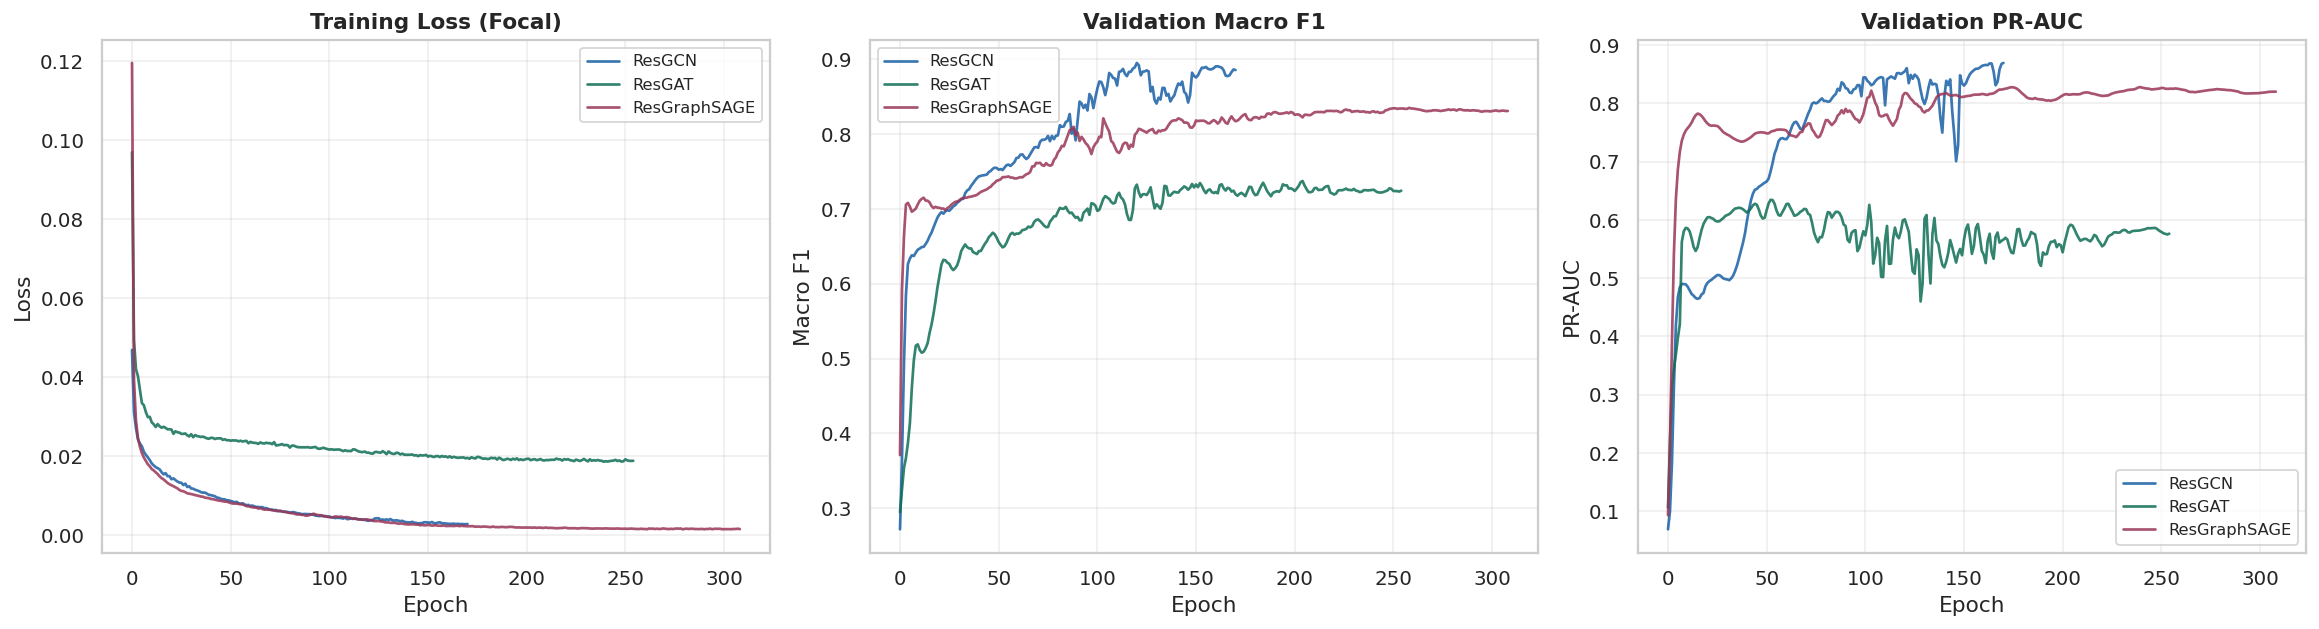

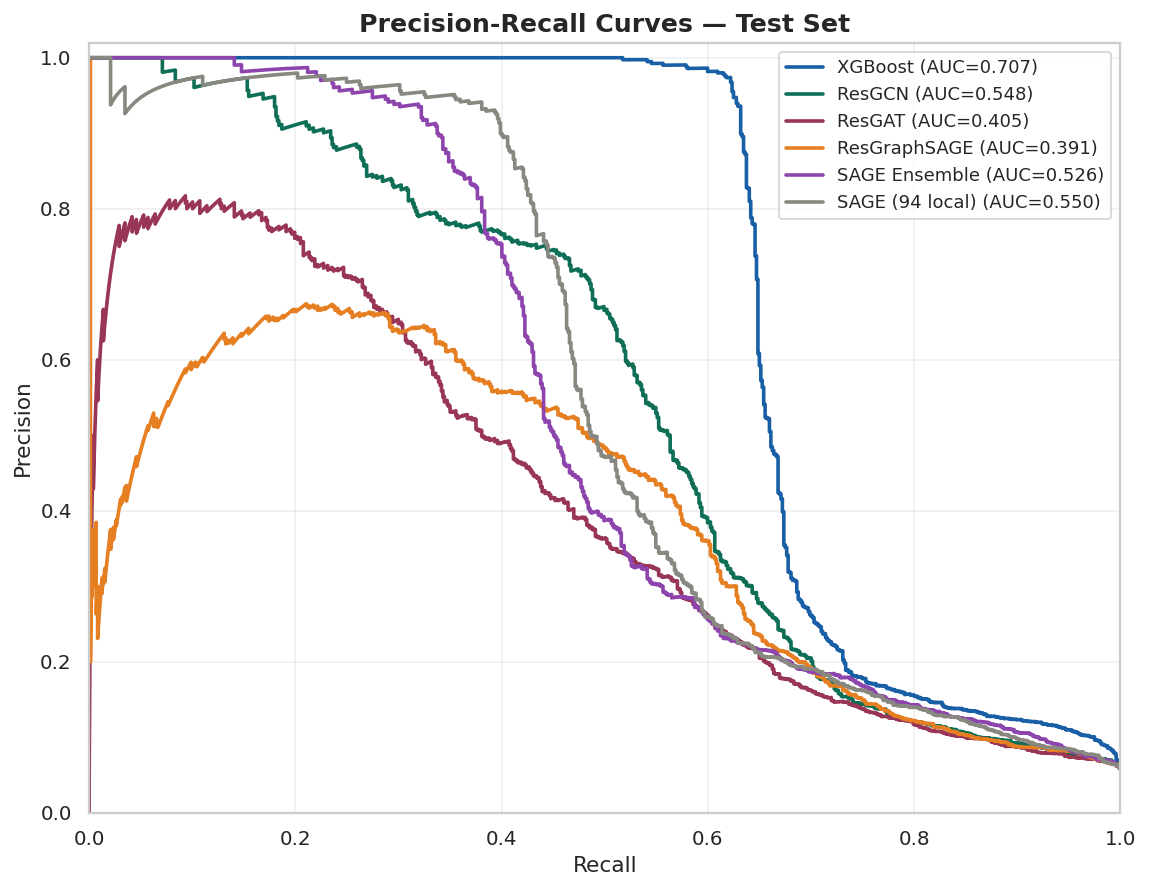

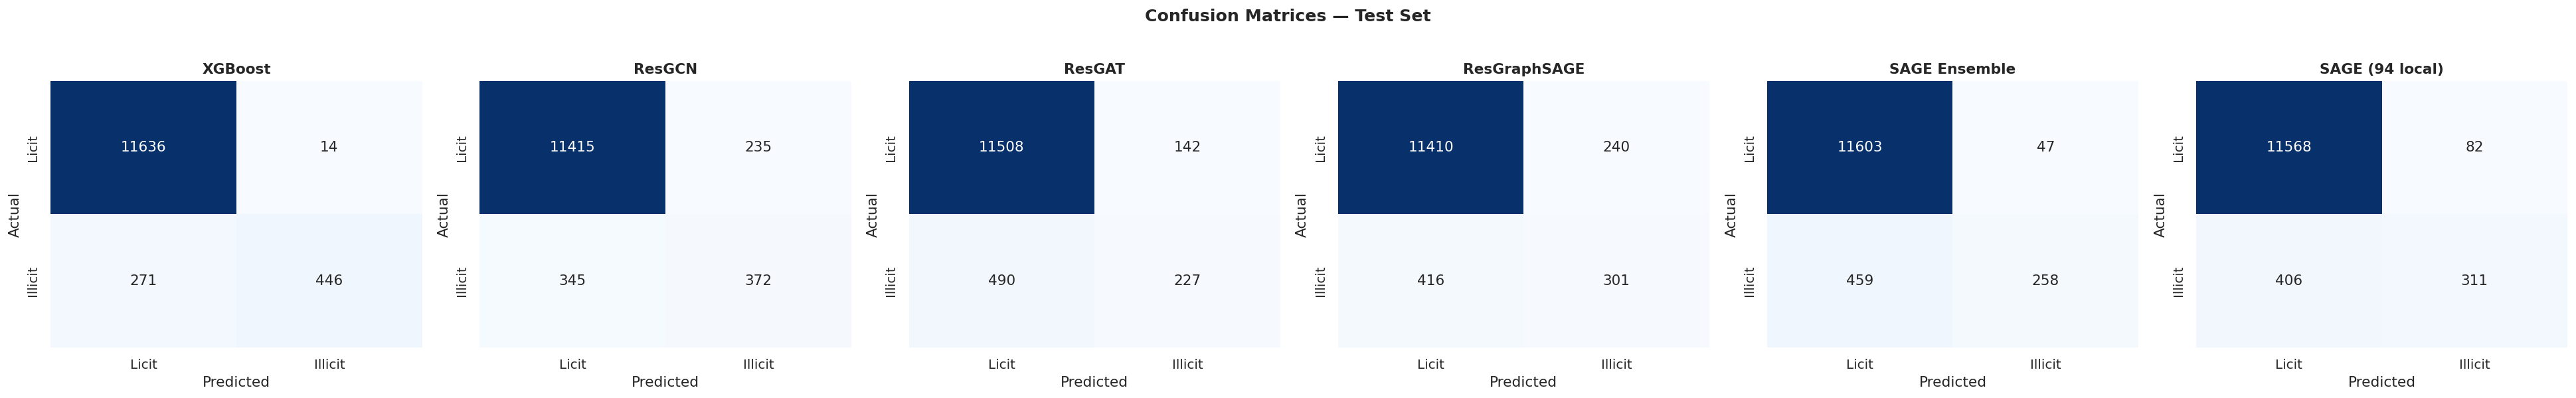

In [14]:
# ═══════════════════════════════════════════════════════════════
    # 12. COMPARISON & VISUALIZATION
    # ═══════════════════════════════════════════════════════════════
print("\n" + "▓" * 60)
print("  PHASE 8: Comparison & Visualization")
print("▓" * 60)

comparison_df = print_comparison_table(all_results)

    # Training curves
if all_histories:
    plot_training_curves(all_histories, all_names)

    # PR curves (only for results that have y_prob)
pr_results = [r for r in all_results if "y_prob" in r]
if pr_results:
        plot_pr_curves(pr_results)
        plot_confusion_matrices(pr_results)


▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  PHASE 9: GNNExplainer (Interpretability)
▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓

GNNExplainer — explaining 3 true-positive nodes
  Node 154383: top features = ['f145', 'f3', 'f138', 'f6', 'f95'], important edges = 2
  Node 154384: top features = ['f154', 'f144', 'f65', 'f112', 'f164'], important edges = 2
  Node 154469: top features = ['f78', 'f61', 'f125', 'f145', 'f55'], important edges = 1


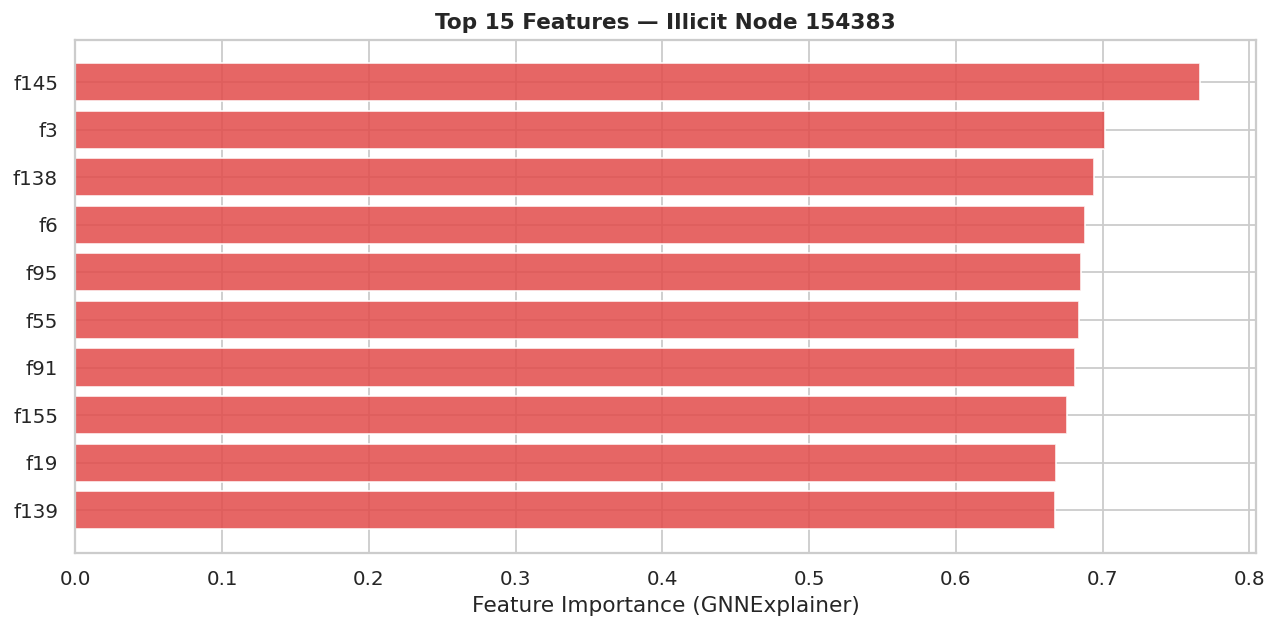

In [15]:
    # ═══════════════════════════════════════════════════════════════
    # 13. GNNEXPLAINER
    # ═══════════════════════════════════════════════════════════════
print("\n" + "▓" * 60)
print("  PHASE 9: GNNExplainer (Interpretability)")
print("▓" * 60)

explain_results = run_gnn_explainer(sage_model, data_full, n_nodes=3)

In [16]:
# ═══════════════════════════════════════════════════════════════
    # 14. SAVE MODELS
    # ═══════════════════════════════════════════════════════════════
torch.save(gcn_model.state_dict(), "resgcn_best.pt")
torch.save(gat_model.state_dict(), "resgat_best.pt")
torch.save(sage_model.state_dict(), "ressage_best.pt")

    # Save comparison table
comparison_df.to_csv("results_comparison.csv", index=False)

print("\n" + "=" * 60)
print("  ALL DONE — Models saved, plots generated.")
print("=" * 60)
print("\nBest model by PR-AUC  :", max(all_results, key=lambda x: x["pr_auc"])["model"])
print("Best model by Macro F1:", max(all_results, key=lambda x: x["macro_f1"])["model"])
print("Best Illicit Recall   :", max(all_results, key=lambda x: x["illicit_recall"])["model"])


  ALL DONE — Models saved, plots generated.

Best model by PR-AUC  : XGBoost
Best model by Macro F1: XGBoost
Best Illicit Recall   : ResGraphSAGE (Rolling)
